<a href="https://colab.research.google.com/github/nastya-kolle/math-statistics/blob/main/Math_Statistics_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Критерии согласия и проверка гипотезы о коэффициенте корреляции

##Часть 1. Критерии согласия

###1. Критерий согласия X**2 Пирсона

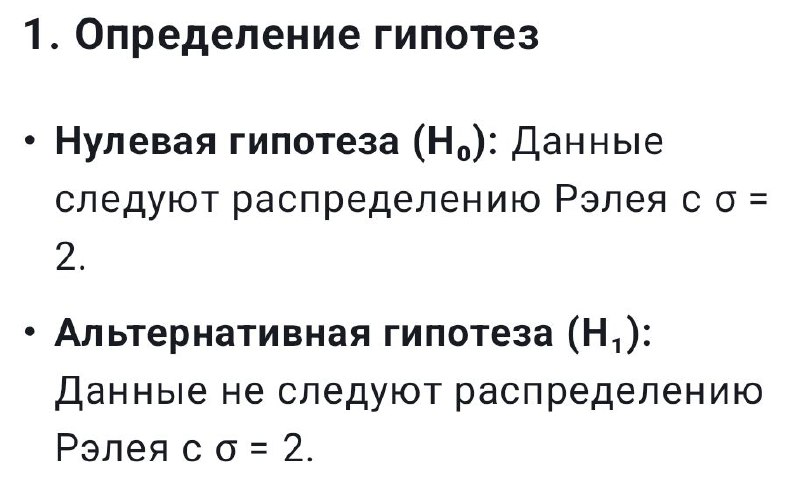

###1.1
С помощью генератора псевдослучайных чисел, встроенного в
математический пакет, сгенерировать выборку с заданным законом
распределения

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy
import scipy.stats as stats
import seaborn as sns

In [ ]:
n=10000
sigma=2
q=np.random.rayleigh(scale=sigma,size=n)
q

array([1.65714397, 5.71192541, 1.01819909, ..., 3.78679847, 3.99038462,
       3.02457205])

###1.2.
Рассчитать значение статистики для критерия X**2 - Пирсона (можно
воспользоваться данными, полученными при расчете гистограммы).

Сначала разобьем на интервалы(бины):
* Выбираем границы интервалов , где a_0=0, a_k=max(q)
* Рассчитываем количество интервалов разбиения k по формуле Стерджесса  k=1+3.322*log n (десятичный логарифм)

In [ ]:
len(q)

10000

In [ ]:
x_min=min(q)
x_min

np.float64(0.014618117544066587)

In [ ]:
x_max=max(q)
x_max

np.float64(8.453837781199327)

Возьмем N=10000

In [ ]:
import math
r=1+math.log(10000,2)#вычисление количества интервалов по формуле Стерджеса
r

14.28771237954945

In [ ]:
K=1+3.322*np.log10(10000)
K

np.float64(14.288)

* Количество интервалов разбиения = 14
* Границы интервала [0.0262;8.601]

In [ ]:
width=(x_max-x_min)/r #ширина интервала группировки
width

np.float64(0.5906627624821618)

In [ ]:
df = pd.DataFrame([x_min, x_max])
partition=pd.cut(q, bins=15).value_counts()
partition

,count
"(0.00618, 0.577]",391
"(0.577, 1.14]",1132
"(1.14, 1.702]",1539
"(1.702, 2.265]",1731
"(2.265, 2.828]",1557
"(2.828, 3.39]",1314
"(3.39, 3.953]",913
"(3.953, 4.516]",660
"(4.516, 5.078]",362
"(5.078, 5.641]",222


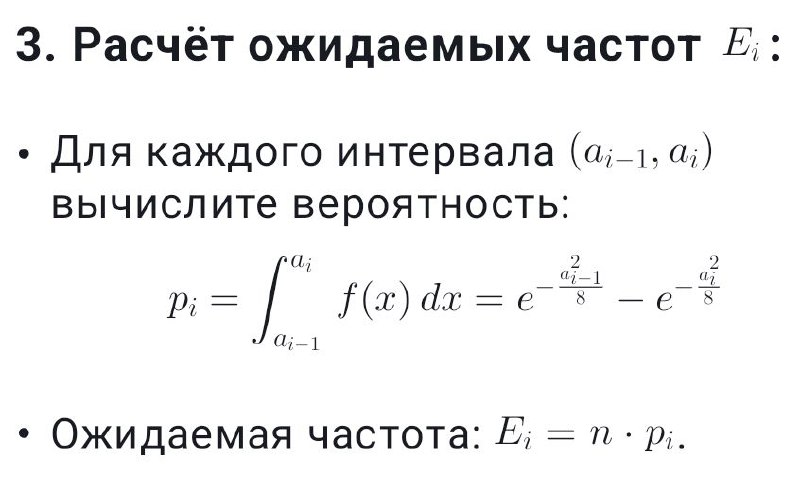

In [ ]:
len(partition)

15

In [ ]:
partition.values

array([ 391, 1132, 1539, 1731, 1557, 1314,  913,  660,  362,  222,  100,
         51,   15,   10,    3])

In [ ]:
partition.index

CategoricalIndex([(0.00618, 0.577],    (0.577, 1.14],    (1.14, 1.702],
                    (1.702, 2.265],   (2.265, 2.828],    (2.828, 3.39],
                     (3.39, 3.953],   (3.953, 4.516],   (4.516, 5.078],
                    (5.078, 5.641],   (5.641, 6.203],   (6.203, 6.766],
                    (6.766, 7.329],   (7.329, 7.891],   (7.891, 8.454]],
                 categories=[(0.00618, 0.577], (0.577, 1.14], (1.14, 1.702], (1.702, 2.265], ..., (6.203, 6.766], (6.766, 7.329], (7.329, 7.891], (7.891, 8.454]], ordered=True, dtype='category')

In [ ]:
def convert(intervals):
  ndarray_of_tuples = np.array([(i.left, i.right) for i in intervals])
  return ndarray_of_tuples

In [ ]:
intervals = pd.IntervalIndex.from_arrays([1, 2], [3, 4])
intervals

IntervalIndex([(1, 3], (2, 4]], dtype='interval[int64, right]')

In [ ]:
convert(intervals)

array([[1, 3],
       [2, 4]])

In [ ]:
partition_converted=convert(partition.index)
partition_converted

array([[6.180e-03, 5.770e-01],
       [5.770e-01, 1.140e+00],
       [1.140e+00, 1.702e+00],
       [1.702e+00, 2.265e+00],
       [2.265e+00, 2.828e+00],
       [2.828e+00, 3.390e+00],
       [3.390e+00, 3.953e+00],
       [3.953e+00, 4.516e+00],
       [4.516e+00, 5.078e+00],
       [5.078e+00, 5.641e+00],
       [5.641e+00, 6.203e+00],
       [6.203e+00, 6.766e+00],
       [6.766e+00, 7.329e+00],
       [7.329e+00, 7.891e+00],
       [7.891e+00, 8.454e+00]])

In [ ]:
len(partition_converted)

15

In [ ]:
def probability_for_interval(partition_converted):

  probability_for_interval=[]
  for row in partition_converted:
    val_0 = row[0]
    val_1 = row[1]

  #for row in range(len(partition_converted)):
  #  val_0 = -1
  #  for value in row:
  #    if val_0==-1:
  #      val_0=value
  #    else:
  #      val_1=value

    probability=np.exp(-(val_0*val_0)/8.0)-np.exp(-(val_1*val_1)/8.0)
    probability_for_interval.append(probability)

  return probability_for_interval

    #partition.index[i]
    #print(partition.index[i])
    #print(type(partition.index[i]))


In [ ]:
probability = probability_for_interval(partition_converted)
probability

[np.float64(0.04075728859331995),
 np.float64(0.10917934527562856),
 np.float64(0.15384619711244918),
 np.float64(0.1695934860564855),
 np.float64(0.15862835138310927),
 np.float64(0.13023507078800264),
 np.float64(0.09594676012831893),
 np.float64(0.06367097785543556),
 np.float64(0.03831275182776265),
 np.float64(0.021094647856765923),
 np.float64(0.0105796463059746),
 np.float64(0.004878672151289052),
 np.float64(0.0020585713903068896),
 np.float64(0.0007969013509546074),
 np.float64(0.00028469718616837405)]

In [ ]:
def expected_frequencies(probability):
  E_i=[]
  for p in probability:
    E_i.append(p*len(q))
  return E_i

In [ ]:
E_i=expected_frequencies(probability)
E_i

[np.float64(407.57288593319953),
 np.float64(1091.7934527562857),
 np.float64(1538.4619711244918),
 np.float64(1695.934860564855),
 np.float64(1586.2835138310927),
 np.float64(1302.3507078800264),
 np.float64(959.4676012831893),
 np.float64(636.7097785543556),
 np.float64(383.1275182776265),
 np.float64(210.94647856765923),
 np.float64(105.796463059746),
 np.float64(48.78672151289052),
 np.float64(20.585713903068896),
 np.float64(7.969013509546074),
 np.float64(2.8469718616837407)]

Вычисление наблюдаемых частот O_i -кол-во значений попавших в интервал

In [ ]:
partition

,count
"(0.00618, 0.577]",391
"(0.577, 1.14]",1132
"(1.14, 1.702]",1539
"(1.702, 2.265]",1731
"(2.265, 2.828]",1557
"(2.828, 3.39]",1314
"(3.39, 3.953]",913
"(3.953, 4.516]",660
"(4.516, 5.078]",362
"(5.078, 5.641]",222


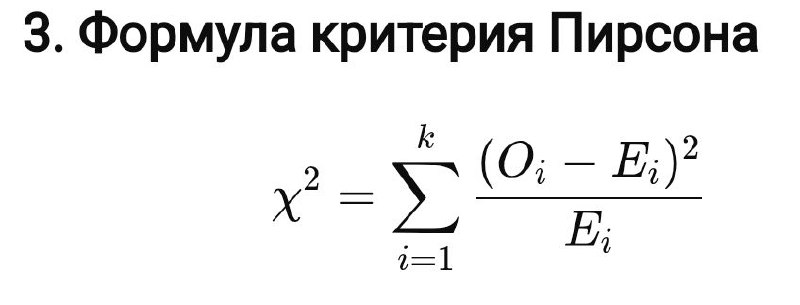

In [ ]:
O_i=partition.values
O_i

array([ 391, 1132, 1539, 1731, 1557, 1314,  913,  660,  362,  222,  100,
         51,   15,   10,    3])

In [ ]:
def Pearson_criterion(O_i,E_i):
  sum=0
  for i in range(len(O_i)):
    if E_i[i] != 0:
      sum+=((O_i[i]-E_i[i])**2)/(E_i[i]*1.0)
  return sum

In [ ]:
pearson_x_2=Pearson_criterion(O_i,E_i)
pearson_x_2

np.float64(10.830648021743285)

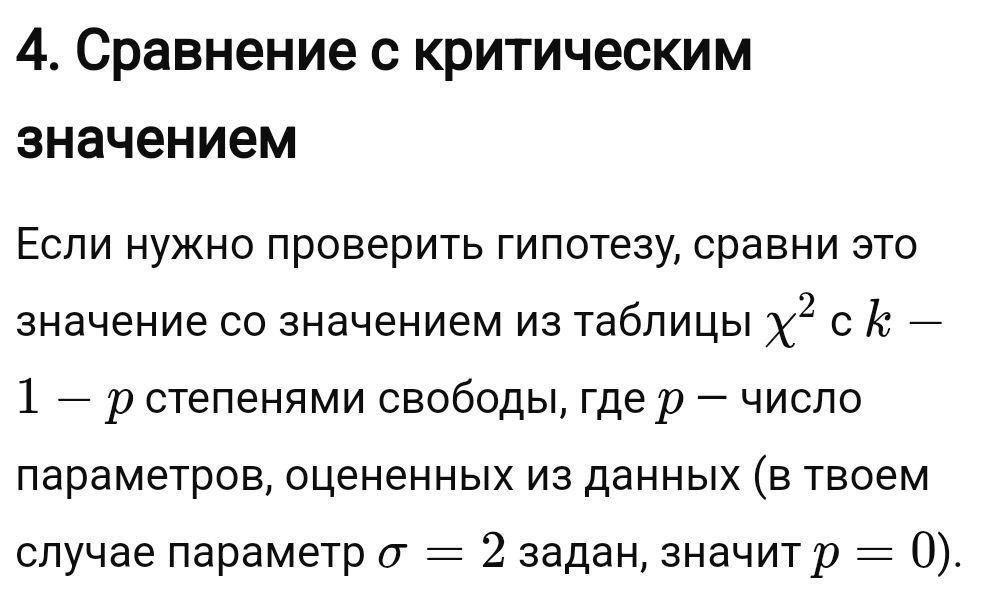

k-1-p => p=0 => k-1 => k=15 => 14 -количество степеней свободы

##1.3.
 Определить при уровнях значимости 0,1, 0,05, 0,01 критические значения

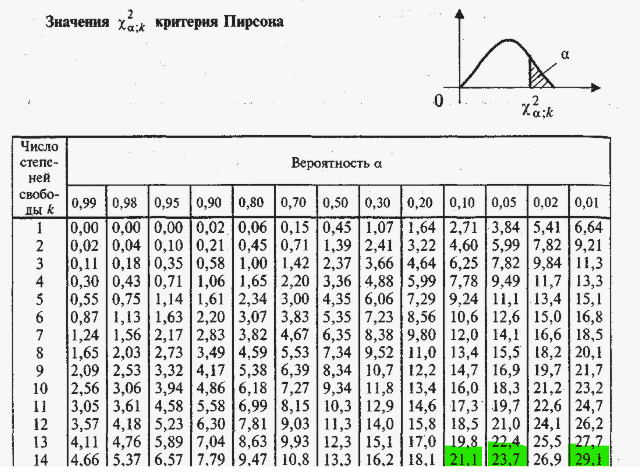

In [ ]:
pearson_x_2

np.float64(10.830648021743285)

* 11.78433 < 21,1
* 11.78433 < 23,7
* 11.78433 < 29,1
=> Принимаем H0 => Данные следуют распределению Рэлея с sigma=2

##2. Критерий Колмогорова

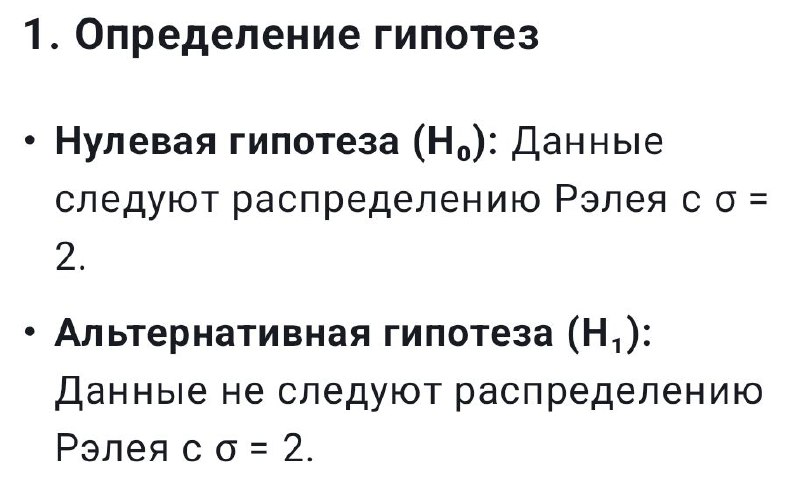

1 Упорядочим выборку

In [ ]:
q.sort()

In [ ]:
q

array([0.01461812, 0.02212551, 0.02494984, ..., 7.91377671, 8.34068873,
       8.45383778])

2 Вычислим эмпирическую CDF

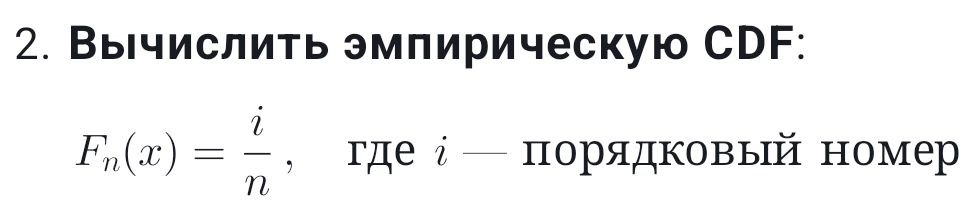

In [ ]:
def get_ECDF():
  F_x=[]
  for i in range(len(q)):
    F_x.append((i*1.0)/len(q))
  return F_x

In [ ]:
ECDF=get_ECDF()
ECDF

[0.0,
 0.0001,
 0.0002,
 0.0003,
 0.0004,
 0.0005,
 0.0006,
 0.0007,
 0.0008,
 0.0009,
 0.001,
 0.0011,
 0.0012,
 0.0013,
 0.0014,
 0.0015,
 0.0016,
 0.0017,
 0.0018,
 0.0019,
 0.002,
 0.0021,
 0.0022,
 0.0023,
 0.0024,
 0.0025,
 0.0026,
 0.0027,
 0.0028,
 0.0029,
 0.003,
 0.0031,
 0.0032,
 0.0033,
 0.0034,
 0.0035,
 0.0036,
 0.0037,
 0.0038,
 0.0039,
 0.004,
 0.0041,
 0.0042,
 0.0043,
 0.0044,
 0.0045,
 0.0046,
 0.0047,
 0.0048,
 0.0049,
 0.005,
 0.0051,
 0.0052,
 0.0053,
 0.0054,
 0.0055,
 0.0056,
 0.0057,
 0.0058,
 0.0059,
 0.006,
 0.0061,
 0.0062,
 0.0063,
 0.0064,
 0.0065,
 0.0066,
 0.0067,
 0.0068,
 0.0069,
 0.007,
 0.0071,
 0.0072,
 0.0073,
 0.0074,
 0.0075,
 0.0076,
 0.0077,
 0.0078,
 0.0079,
 0.008,
 0.0081,
 0.0082,
 0.0083,
 0.0084,
 0.0085,
 0.0086,
 0.0087,
 0.0088,
 0.0089,
 0.009,
 0.0091,
 0.0092,
 0.0093,
 0.0094,
 0.0095,
 0.0096,
 0.0097,
 0.0098,
 0.0099,
 0.01,
 0.0101,
 0.0102,
 0.0103,
 0.0104,
 0.0105,
 0.0106,
 0.0107,
 0.0108,
 0.0109,
 0.011,
 0.0111,
 0.0112

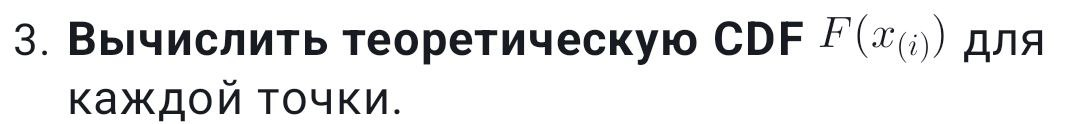

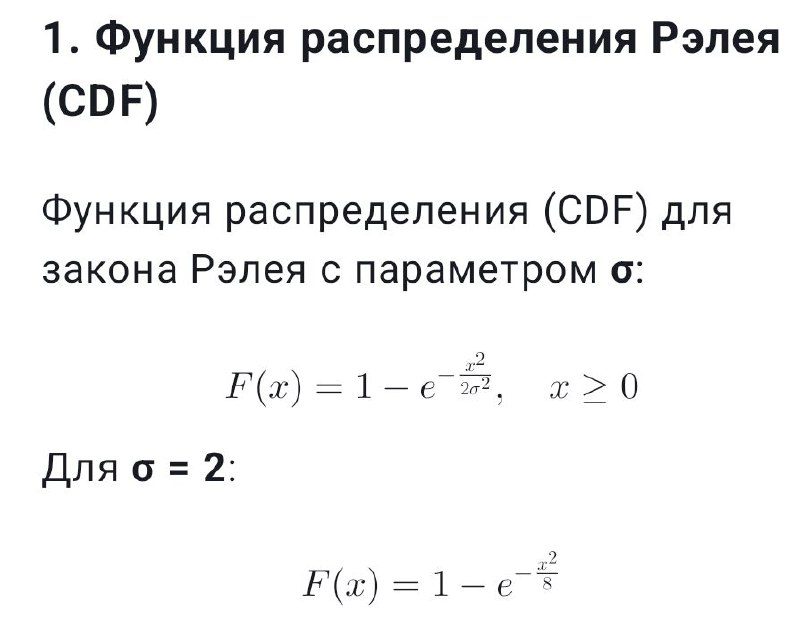

In [ ]:
def get_CDF(q):
  F_x=[]
  for x in range(len(q)):
    res=1-np.exp(-(q[x]**2)/8.0)
    F_x.append(res)
  return F_x

In [ ]:
CDF=get_CDF(q)

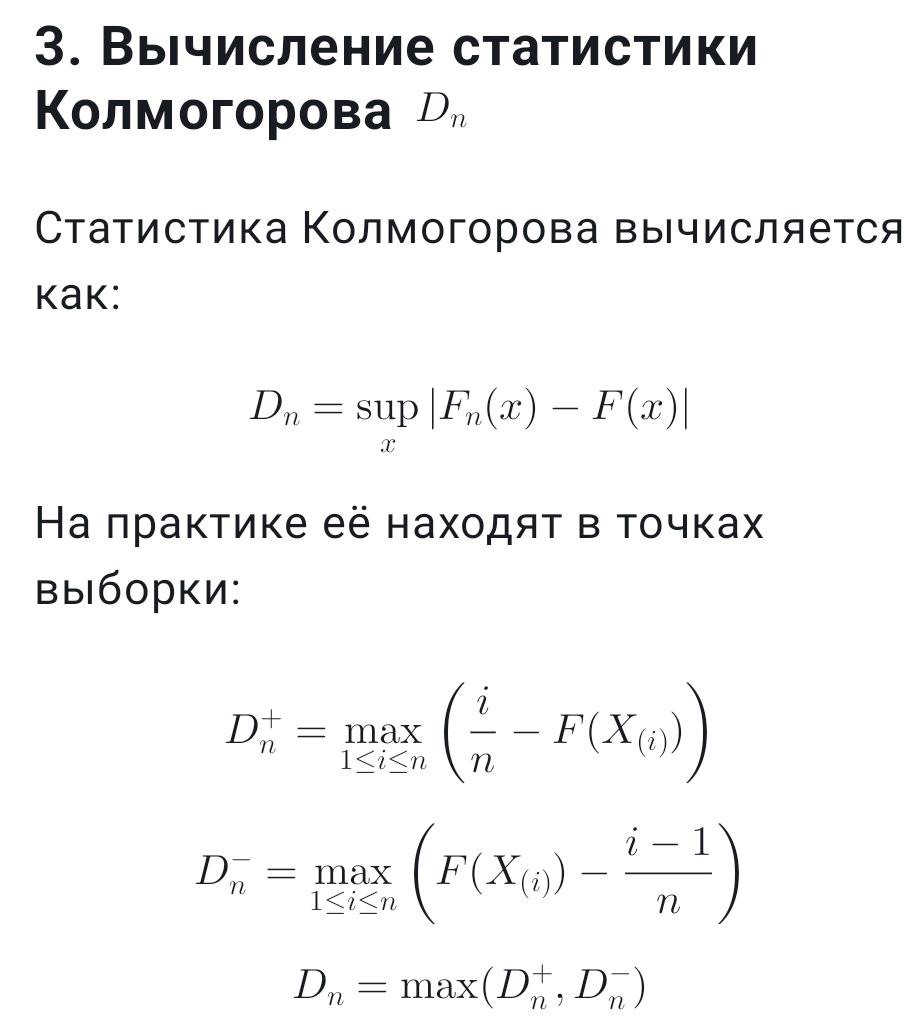

In [ ]:
def get_Kolmogorov_criterion(ECDF,CDF):
  res=[]
  for i in range(len(ECDF)):
    res.append(ECDF[i]-CDF[i])
  max=np.max(res)
  return max

In [ ]:
D_1=get_Kolmogorov_criterion(ECDF,CDF)
D_1

np.float64(0.007742590461283949)

In [ ]:
def get_ECDF_():
  F_x=[]
  for i in range(len(q)):
    F_x.append(((i-1)*1.0)/len(q))
  return F_x

In [ ]:
ECDF_=get_ECDF_()
ECDF_

[-0.0001,
 0.0,
 0.0001,
 0.0002,
 0.0003,
 0.0004,
 0.0005,
 0.0006,
 0.0007,
 0.0008,
 0.0009,
 0.001,
 0.0011,
 0.0012,
 0.0013,
 0.0014,
 0.0015,
 0.0016,
 0.0017,
 0.0018,
 0.0019,
 0.002,
 0.0021,
 0.0022,
 0.0023,
 0.0024,
 0.0025,
 0.0026,
 0.0027,
 0.0028,
 0.0029,
 0.003,
 0.0031,
 0.0032,
 0.0033,
 0.0034,
 0.0035,
 0.0036,
 0.0037,
 0.0038,
 0.0039,
 0.004,
 0.0041,
 0.0042,
 0.0043,
 0.0044,
 0.0045,
 0.0046,
 0.0047,
 0.0048,
 0.0049,
 0.005,
 0.0051,
 0.0052,
 0.0053,
 0.0054,
 0.0055,
 0.0056,
 0.0057,
 0.0058,
 0.0059,
 0.006,
 0.0061,
 0.0062,
 0.0063,
 0.0064,
 0.0065,
 0.0066,
 0.0067,
 0.0068,
 0.0069,
 0.007,
 0.0071,
 0.0072,
 0.0073,
 0.0074,
 0.0075,
 0.0076,
 0.0077,
 0.0078,
 0.0079,
 0.008,
 0.0081,
 0.0082,
 0.0083,
 0.0084,
 0.0085,
 0.0086,
 0.0087,
 0.0088,
 0.0089,
 0.009,
 0.0091,
 0.0092,
 0.0093,
 0.0094,
 0.0095,
 0.0096,
 0.0097,
 0.0098,
 0.0099,
 0.01,
 0.0101,
 0.0102,
 0.0103,
 0.0104,
 0.0105,
 0.0106,
 0.0107,
 0.0108,
 0.0109,
 0.011,
 0.011

In [ ]:
def get_Kolmogorov_criterion_(ECDF_,CDF):
  res=[]
  for i in range(len(CDF)):
    res.append(CDF[i]-ECDF_[i])
  max=np.max(res)
  return max

In [ ]:
D_2=get_Kolmogorov_criterion_(ECDF_,CDF)
D_2

np.float64(0.002294955120968646)

In [ ]:
D=max(D_1, D_2)
D

np.float64(0.007742590461283949)

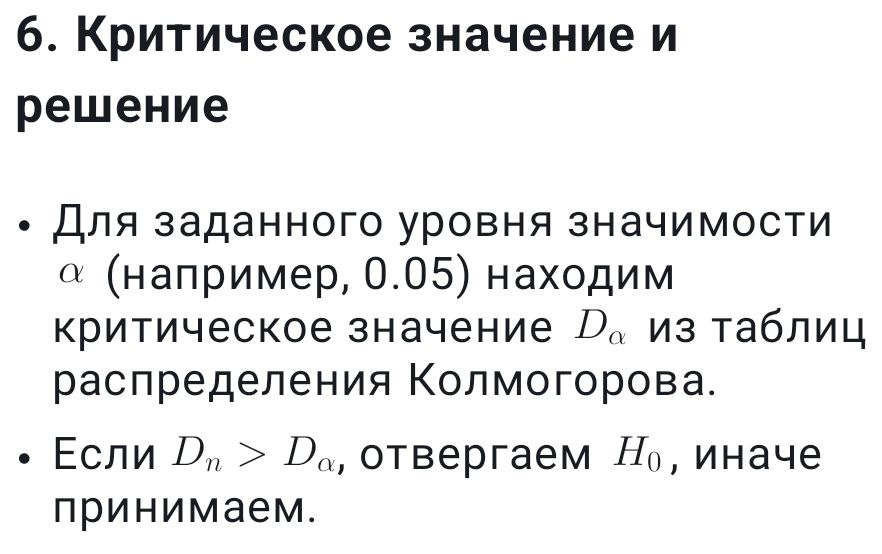

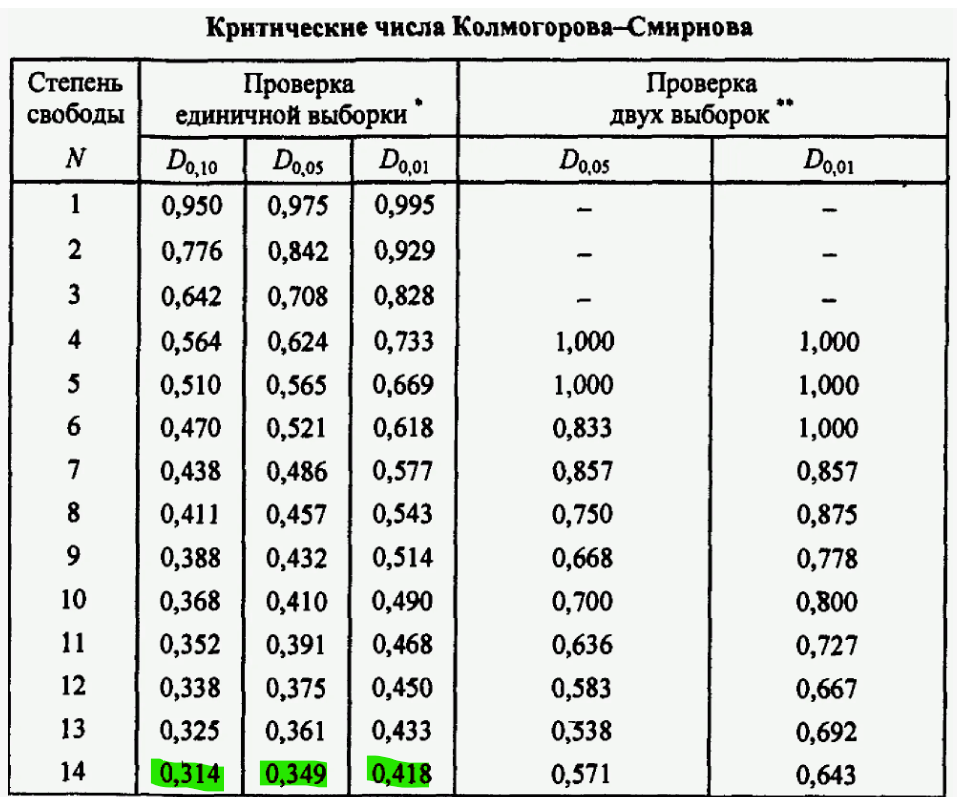

* 0.00977 < 0,314
* 0.00977 < 0,349
* 0.00977 < 0,418
=> D < D_a => Принимаем H0 => Данные следуют распределению Рэлея с sigma=2

#Часть 2. Проверка гипотезы о коэффициенте корреляции

Сгенерировать 2 выборки:
*  Массив X из распределения, заданного вам при выполнении Л.р.№1
*  Массив Y из того же самого распределения, с теми же самыми значениями
параметров, что и для массива X. Но поскольку вы генерируете с помощью
генератора псевдослучайных чисел, то они не будут одинаковыми

In [ ]:
n=10000
sigma=2
X=np.random.rayleigh(scale=sigma,size=n)
X

array([1.21774831, 3.54946162, 1.32952036, ..., 1.75341848, 2.23015795,
       0.92751741])

In [ ]:
Y=np.random.rayleigh(scale=sigma,size=n)
Y

array([5.648835  , 3.62259143, 1.39711183, ..., 1.80336241, 2.79451663,
       4.96910801])

* Рассчитать коэффициент корреляции и сделать вывод о соотношении между
случайными величинами

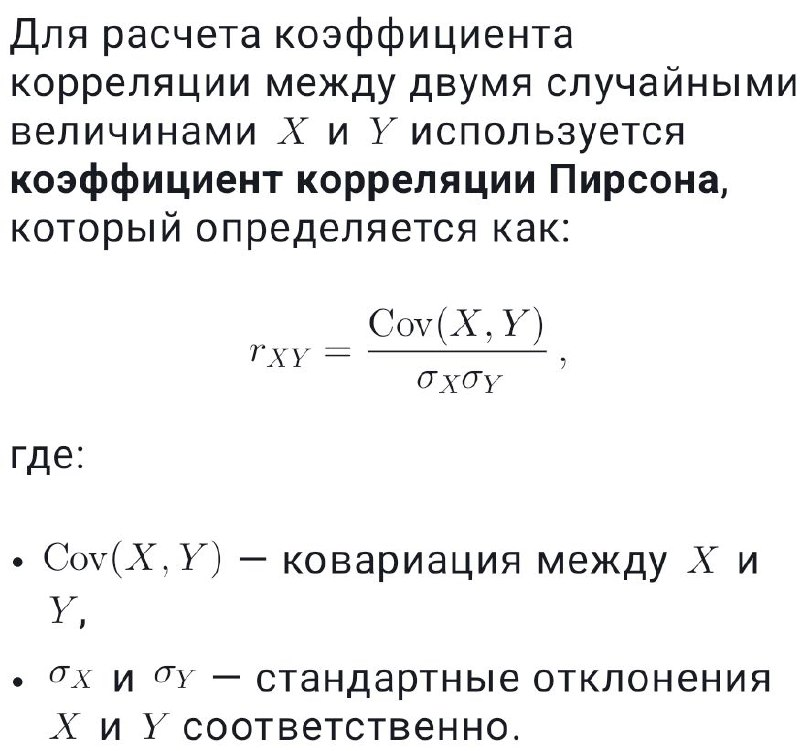

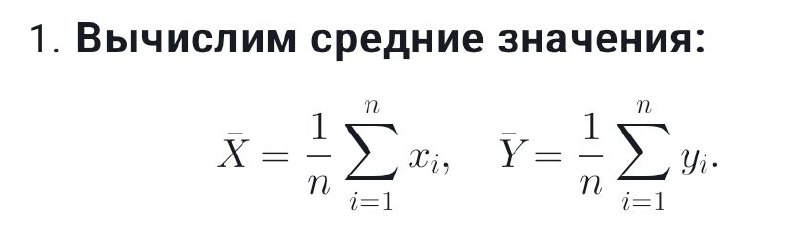

In [ ]:
x_mean=np.mean(X)
x_mean

np.float64(2.52768038922432)

In [ ]:
y_mean=np.mean(Y)
y_mean

np.float64(2.4882737700309203)

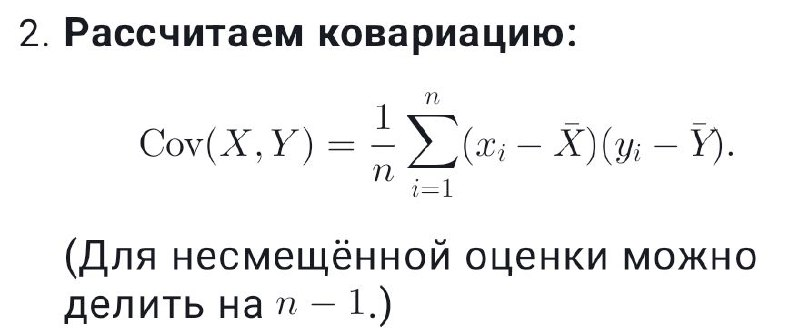

In [ ]:
def covariation(X,Y,x_mean,y_mean):
  sum=0
  for i in range(len(X)):
    res_1=X[i]-x_mean
    res_2=Y[i]-y_mean
    sum+=res_1*res_2
  cov=(sum*1.0)/len(X)
  return cov

In [ ]:
cov=covariation(X,Y,x_mean,y_mean)
cov

np.float64(-0.0016574727927964308)

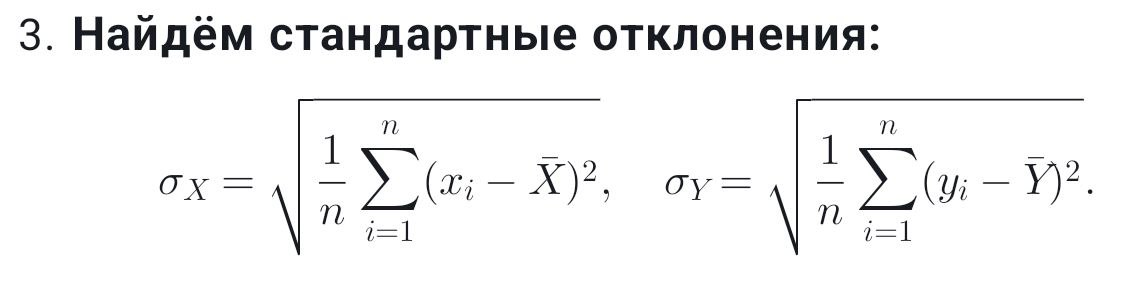

In [ ]:
def standart_deviation_x(X, x_mean):
  sum=0
  for i in range(len(X)):
    res=X[i]-x_mean
    sum+=res**2
  sigma_x=(sum*1.0)/len(X)
  return sigma_x

In [ ]:
def standart_deviation_y(Y, y_mean):
  sum=0
  for i in range(len(Y)):
    res=Y[i]-y_mean
    sum+=res**2
  sigma_y=(sum*1.0)/len(Y)
  return sigma_y

In [ ]:
sigma_x=standart_deviation_x(X, x_mean)
sigma_x

np.float64(1.7275171543530818)

In [ ]:
sigma_y=standart_deviation_y(Y, y_mean)
sigma_y

np.float64(1.67930521619109)

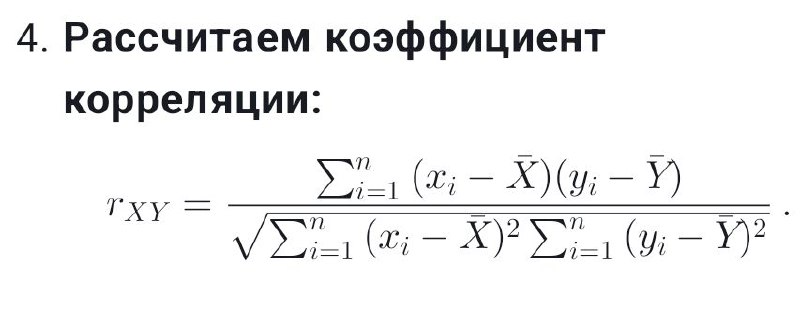

In [ ]:
def coefficient_correlation(cov,sigma_x, sigma_y):
  r_xy=cov/(sigma_x*sigma_y*1.0)
  return r_xy

In [ ]:
coeff=coefficient_correlation(cov,sigma_x, sigma_y)
coeff

np.float64(-0.0005713397002948964)

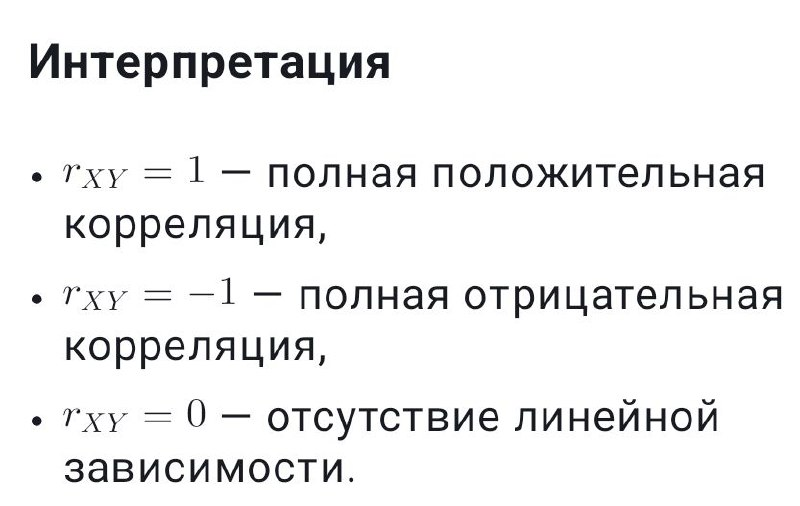

coeff = 0.00913 =>отсутствует линейная зависимость

* Рассчитать значение статистики T

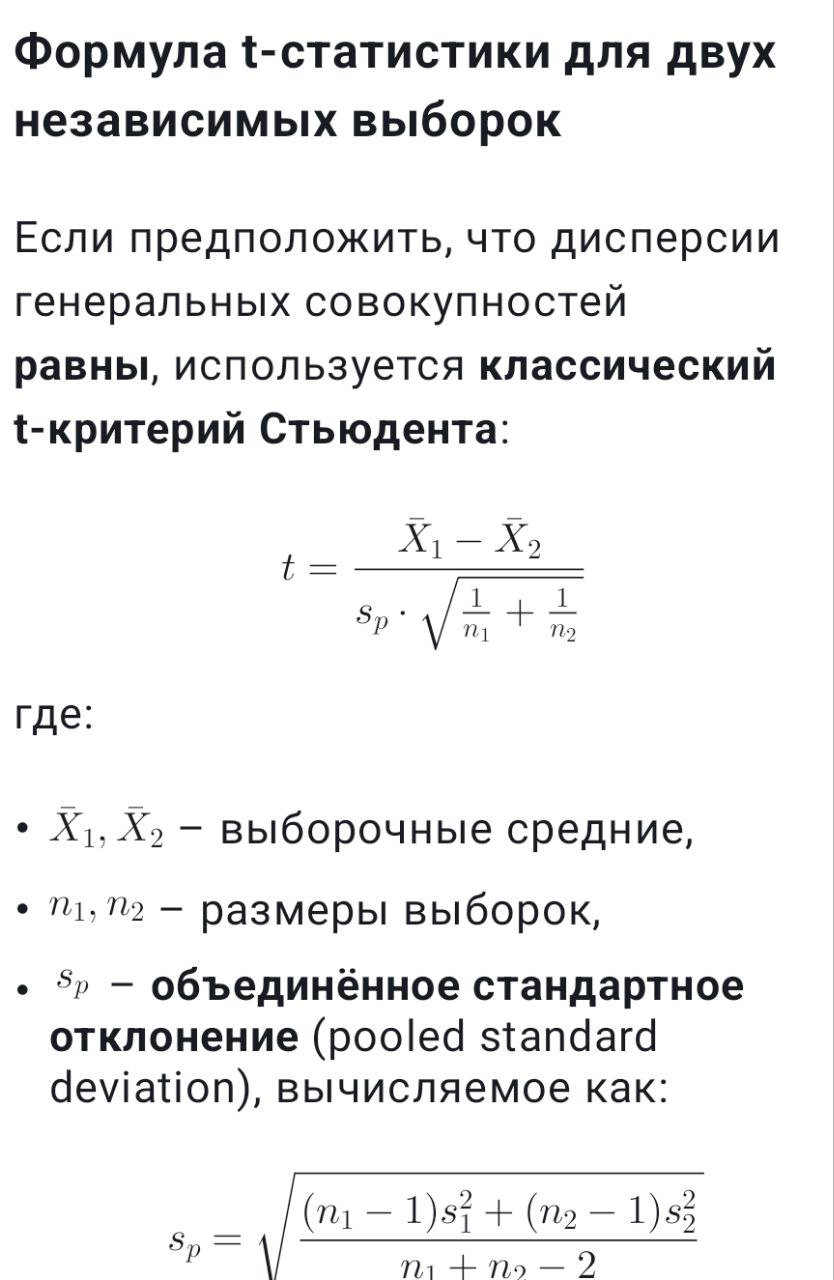

Дисперсии X и Y равны, т к sigma_x = 1.7275, sigma_y = 1.6793

In [ ]:
def Student_statistics(x_mean, y_mean, X, Y, sigma_x, sigma_y):
  s=np.sqrt(((len(X)-1)*(sigma_x**2)+(len(Y)-1)*(sigma_y**2)*1.0)/(len(X)+len(Y)-2))
  res_1=x_mean-y_mean
  res_2=s*np.sqrt(1.0/len(X)+1.0/len(Y))
  res=(res_1*1.0)/res_2
  return res

In [ ]:
T_statistics=Student_statistics(x_mean, y_mean, X, Y, sigma_x, sigma_y)
T_statistics

np.float64(1.6356531013361257)

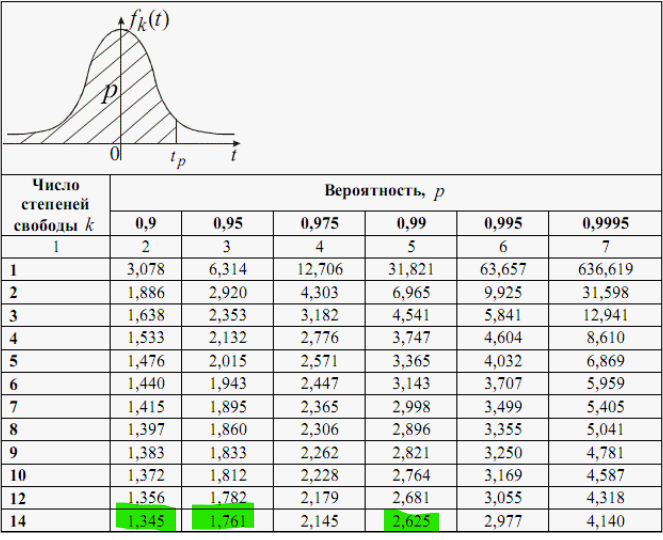

T_statistics = 1.6356
* 1.6356 > 1,345 => Незначимые различия => Принимается H0
* 1.6356 < 1,761 => Значимые различия => Отвергается H0
* 1.6356 < 2,625 => Значимые различия => Отвергается H0

* Проделать пункты 3-6 при условии что выборка X выбирается как в п.1, а
выборка Y формируется из X по закону Y=2*X+b. Где под b понимается
выборка из нормального распределения с математическим ожиданием 0 и
среднеквадратическим отклонением σ=0.001, 100, 1000.

In [ ]:
X

array([1.21774831, 3.54946162, 1.32952036, ..., 1.75341848, 2.23015795,
       0.92751741])

In [ ]:
len(X)

10000

Возьмем sigma = 0.001

In [ ]:
mu=0
sigma=0.001
n=10000
sample=np.random.normal(mu,sigma,n)
sample

array([-0.00018086, -0.00049064, -0.00015018, ...,  0.00257623,
       -0.00105624, -0.00113596])

In [ ]:
def get_Y(X, sample):
  Y=[]
  for i in range(len(X)):
    Y.append(2*X[i]+sample[i])
  return Y

In [ ]:
Y=get_Y(X, sample)
Y

[np.float64(2.435315766268407),
 np.float64(7.098432595080189),
 np.float64(2.6588905324951937),
 np.float64(7.1420505411470145),
 np.float64(9.325990510001025),
 np.float64(5.960997982923338),
 np.float64(2.151864424169465),
 np.float64(3.869574058287339),
 np.float64(7.727479440976825),
 np.float64(3.5440212198148893),
 np.float64(3.023225320635028),
 np.float64(4.310776848470621),
 np.float64(6.047925665492292),
 np.float64(1.255108995613692),
 np.float64(5.232586310528998),
 np.float64(5.509006282493733),
 np.float64(5.831379519879869),
 np.float64(7.602207401953861),
 np.float64(4.6207005898557405),
 np.float64(0.9825293670593865),
 np.float64(4.977559534557382),
 np.float64(1.2175587085348707),
 np.float64(4.587933270830496),
 np.float64(7.581897728281173),
 np.float64(6.980650650145498),
 np.float64(3.0101153541618277),
 np.float64(5.711144111388619),
 np.float64(3.388553582585659),
 np.float64(2.8852601655909527),
 np.float64(9.030277229885135),
 np.float64(4.25716618154963),
 

In [ ]:
x_mean=np.mean(X)
x_mean

np.float64(2.52768038922432)

In [ ]:
y_mean=np.mean(Y)
y_mean

np.float64(5.055363331101421)

In [ ]:
def covariation(X,Y,x_mean,y_mean):
  sum=0
  for i in range(len(X)):
    res_1=X[i]-x_mean
    res_2=Y[i]-y_mean
    sum+=res_1*res_2
  cov=(sum*1.0)/len(X)
  return cov

In [ ]:
cov=covariation(X,Y,x_mean,y_mean)
cov

np.float64(3.455025817524268)

In [ ]:
def standart_deviation_x(X, x_mean):
  sum=0
  for i in range(len(X)):
    res=X[i]-x_mean
    sum+=res**2
  sigma_x=(sum*1.0)/len(X)
  return sigma_x

In [ ]:
def standart_deviation_y(Y, y_mean):
  sum=0
  for i in range(len(Y)):
    res=Y[i]-y_mean
    sum+=res**2
  sigma_y=(sum*1.0)/len(Y)
  return sigma_y

In [ ]:
sigma_x=standart_deviation_x(X, x_mean)
sigma_x

np.float64(1.7275171543530818)

In [ ]:
sigma_y=standart_deviation_y(Y, y_mean)
sigma_y

np.float64(6.910035648522761)

In [ ]:
def coefficient_correlation(cov,sigma_x, sigma_y):
  r_xy=cov/(sigma_x*sigma_y*1.0)
  return r_xy

In [ ]:
coeff=coefficient_correlation(cov,sigma_x, sigma_y)
coeff

np.float64(0.28943339607454965)

coeff = 0.2894 => отсутствует линейная зависимость

In [ ]:
def Student_statistics(x_mean, y_mean, X, Y, sigma_x, sigma_y):
  s=np.sqrt(((len(X)-1)*(sigma_x**2)+(len(Y)-1)*(sigma_y**2)*1.0)/(len(X)+len(Y)-2))
  res_1=x_mean-y_mean
  res_2=s*np.sqrt(1.0/len(X)+1.0/len(Y))
  res=(res_1*1.0)/res_2
  return res

In [ ]:
T_statistics=Student_statistics(x_mean, y_mean, X, Y, sigma_x, sigma_y)
T_statistics

np.float64(-35.48768899768)

-35.4876 < любая статистика Стьюдента => H0 отвергается => Значимые различия

Возьмем sigma = 100

In [ ]:
mu=0
sigma=100
n=10000
sample=np.random.normal(mu,sigma,n)
sample

array([ -63.05075655, -210.5969449 ,  107.95074914, ..., -145.33124509,
         61.27916398,   36.59321054])

In [ ]:
Y=get_Y(X, sample)
Y

[np.float64(-60.615259923319684),
 np.float64(-203.49802166190761),
 np.float64(110.60978986131585),
 np.float64(42.688637319961),
 np.float64(43.72900330690752),
 np.float64(-113.73109486813273),
 np.float64(-88.17893895973924),
 np.float64(5.772816663230031),
 np.float64(-136.82262118663397),
 np.float64(-55.48615488440071),
 np.float64(-30.766894156542712),
 np.float64(69.20856269691589),
 np.float64(54.00665480547976),
 np.float64(-103.20229078769496),
 np.float64(236.7010662377319),
 np.float64(112.57936077411618),
 np.float64(187.66833845270625),
 np.float64(69.32191909422242),
 np.float64(-152.56750945177075),
 np.float64(-33.84807365897264),
 np.float64(73.31351623866819),
 np.float64(113.4807469543792),
 np.float64(0.03201449289604952),
 np.float64(5.24052139846969),
 np.float64(-78.71911502956956),
 np.float64(9.592750374069904),
 np.float64(112.45587638712303),
 np.float64(122.7663833359447),
 np.float64(-288.4589265584494),
 np.float64(-168.68393369888568),
 np.float64(126.

In [ ]:
y_mean=np.mean(Y)
y_mean

np.float64(4.76168991560755)

In [ ]:
cov=covariation(X,Y,x_mean,y_mean)
cov

np.float64(1.9389130943515647)

In [ ]:
sigma_x=standart_deviation_x(X, x_mean)
sigma_x

np.float64(1.7275171543530818)

In [ ]:
sigma_y=standart_deviation_y(Y, y_mean)
sigma_y

np.float64(10320.613811049454)

In [ ]:
coeff=coefficient_correlation(cov,sigma_x, sigma_y)
coeff

np.float64(0.00010875029597108682)

coeff = 0.00010875 => Отсуствует линейная зависимость

In [ ]:
T_statistics=Student_statistics(x_mean, y_mean, X, Y, sigma_x, sigma_y)
T_statistics

np.float64(-0.0216460913661498)

T_statistics = -0.021646 < любая статистика Стьюдента =>  H0 отвергается => Значимые различия

Возьмем sigma = 1000

In [ ]:
mu=0
sigma=1000
n=10000
sample=np.random.normal(mu,sigma,n)
sample

array([  236.07286377,  1768.63278008,   106.48653745, ...,
        1099.75343832,  -663.97709403, -1268.93234184])

In [ ]:
Y=get_Y(X, sample)
Y

[np.float64(238.5083603933556),
 np.float64(1775.7317033213778),
 np.float64(109.14557816924963),
 np.float64(-483.907664084944),
 np.float64(1634.3985571131152),
 np.float64(-851.8816066566739),
 np.float64(-1764.789567296802),
 np.float64(194.30573961039136),
 np.float64(1025.388556662297),
 np.float64(418.80111103628064),
 np.float64(-466.95016779629935),
 np.float64(-1432.7646182833637),
 np.float64(592.4829494817538),
 np.float64(271.5887766442417),
 np.float64(305.9178437078207),
 np.float64(-877.184520213497),
 np.float64(-1103.22022474892),
 np.float64(-1650.441066210133),
 np.float64(-939.9129288457913),
 np.float64(1368.7096999790208),
 np.float64(71.11888020738402),
 np.float64(-1504.892705264649),
 np.float64(-29.58719440499051),
 np.float64(-880.1507033012525),
 np.float64(1587.1105248711524),
 np.float64(-1020.4618895126604),
 np.float64(-162.96285046666844),
 np.float64(1150.2339075875088),
 np.float64(-444.41581415678854),
 np.float64(255.0728849082652),
 np.float64(247

In [ ]:
y_mean=np.mean(Y)
y_mean

np.float64(-7.191797176213402)

In [ ]:
cov=covariation(X,Y,x_mean,y_mean)
cov

np.float64(9.466520649375022)

In [ ]:
sigma_x=standart_deviation_x(X, x_mean)
sigma_x

np.float64(1.7275171543530818)

In [ ]:
sigma_y=standart_deviation_y(Y, y_mean)
sigma_y

np.float64(980332.0385510079)

In [ ]:
coeff=coefficient_correlation(cov,sigma_x, sigma_y)
coeff

np.float64(5.58978136782821e-06)

coeff = 5.58978136782821e-06 => Отсуствует линейная зависимость

In [ ]:
T_statistics=Student_statistics(x_mean, y_mean, X, Y, sigma_x, sigma_y)
T_statistics

np.float64(0.000991447507906467)

T_statistics = 0.0009914 < любая статистика Стьюдента =>  H0 отвергается => Значимые различия